# Assignment 9: Xarray Fundamentals with Atmospheric Radiation Data

In this assignment, we will use Xarray to analyze top-of-atmosphere radiation data from NASA’s CERES project.

In [197]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)
import cartopy 
import cartopy.crs as ccrs

In [198]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/ktw2128/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


Please review the CERES FAQs before getting started.

https://ceres.larc.nasa.gov/resources/faqs/

## 1) Opening data and examining metadata

### 1.1) Open the dataset and display its contents

In [199]:
ds = xr.open_dataset(fname)
ds

<xarray.Dataset> Size: 737MB
Dimensions:                      (lon: 360, time: 203, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

In [200]:
ds.info()

xarray.Dataset {
dimensions:
	lon = 360 ;
	time = 203 ;
	lat = 180 ;

variables:
	float32 lon(lon) ;
		lon:long_name = longitude ;
		lon:standard_name = longitude ;
		lon:units = degrees_east ;
		lon:valid_range = [  0. 360.] ;
	float32 toa_sw_all_mon(time, lat, lon) ;
		toa_sw_all_mon:long_name = Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions ;
		toa_sw_all_mon:standard_name = TOA Shortwave Flux - All-Sky ;
		toa_sw_all_mon:CF_name = toa_outgoing_shortwave_flux ;
		toa_sw_all_mon:units = W m-2 ;
		toa_sw_all_mon:valid_min =       0.00000 ;
		toa_sw_all_mon:valid_max =       600.000 ;
	float32 toa_lw_all_mon(time, lat, lon) ;
		toa_lw_all_mon:long_name = Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions ;
		toa_lw_all_mon:standard_name = TOA Longwave Flux - All-Sky ;
		toa_lw_all_mon:CF_name = toa_outgoing_longwave_flux ;
		toa_lw_all_mon:units = W m-2 ;
		toa_lw_all_mon:valid_min =       0.00000 ;
		toa_lw_all_mon:valid_max =       400.000

### 1.2) Print out the long_name attribute of each variable
Print variable: long name for each variable. Format the output so that the start of the long name attributes are aligned.

In [201]:
ds.variables

Frozen({'lon': <xarray.IndexVariable 'lon' (lon: 360)> Size: 1kB
array([  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5], dtype=float32)
Attributes:
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east
    valid_range:    [  0. 360.], 'toa_sw_all_mon': <xarray.Variable (time: 203, lat: 180, lon: 360)> Size: 53MB
[13154400 values with dtype=float32]
Attributes:
    long_name:      Top of The Atmosphere Shortwave Flux, Monthly Means, All-...
    standard_name:  TOA Shortwave Flux - All-Sky
    CF_name:        toa_outgoing_shortwave_flux
    units:          W m-2
    valid_min:            0.00000
    valid_max:            600.000, 'toa_lw_all_mon': <xarray.Variable (time: 203, lat: 180, lon: 360)> Size: 53MB
[13154400 values with dtype=float32]
Attributes:
    long_name:      Top of The Atmosphere Longwave Flux, Monthly Means, All-S...
    standard_name:  TOA Longwave Flux - All-Sky
    CF_name:        toa_outgoing_longwave_flux
    units:          W 

In [202]:
print("Long Name Attribute of Each Variable")
for var in ds.variables:
    long = ds[var].attrs.get('long_name')
    print(f"{var:30} : {long}")

Long Name Attribute of Each Variable
lon                            : longitude
toa_sw_all_mon                 : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon                 : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon                : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon                 : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon                 : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon                : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon                 : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon                 : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon                : Top of The Atmosphere Cloud Radiative Effects Ne

## 2) Basic reductions, arithmetic, and plotting

### 2.1) Calculate the time-mean of the entire dataset

In [203]:
time_mean = ds.mean(dim = 'time')
time_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lon: 360, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

### 2.2) From this, make a 2D plot of the the time-mean Top of Atmosphere (TOA) Longwave, Shortwave, and Incoming Solar Radiation.

(Use “All-Sky” conditions)

Note the sign conventions on each variable.

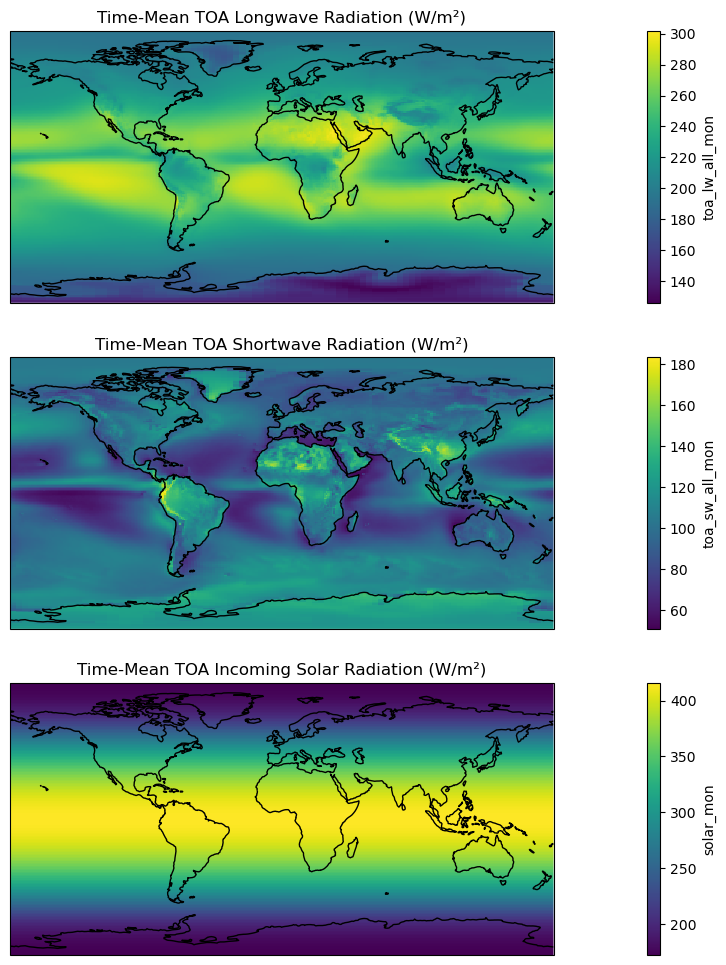

In [204]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 3, figsize = (24, 12), subplot_kw={'projection': ccrs.PlateCarree()}) 

time_mean.toa_lw_all_mon.plot(ax=ax1, x='lon', y='lat')
ax1.set_title('Time-Mean TOA Longwave Radiation (W/m²)')
ax1.coastlines() 

time_mean.toa_sw_all_mon.plot(ax=ax2, x='lon', y='lat')
ax2.set_title('Time-Mean TOA Shortwave Radiation (W/m²)')
ax2.coastlines() 

time_mean.solar_mon.plot(ax=ax3, x='lon', y='lat')
ax3.set_title('Time-Mean TOA Incoming Solar Radiation (W/m²)')
ax3.coastlines()

plt.show()

### 2.3) Add up the three variables above and verify (visually) that they are equivalent to the TOA net flux

You have to pay attention to and think carefully about the sign conventions (positive or negative) for each variable in order for the variables to sum to the right TOA net flux. Refer to the NASA figure at the top of the assignment page to understand incoming and outgoing radiation.

Calculated TOA New Flux (W/m^2): -28.72899055480957


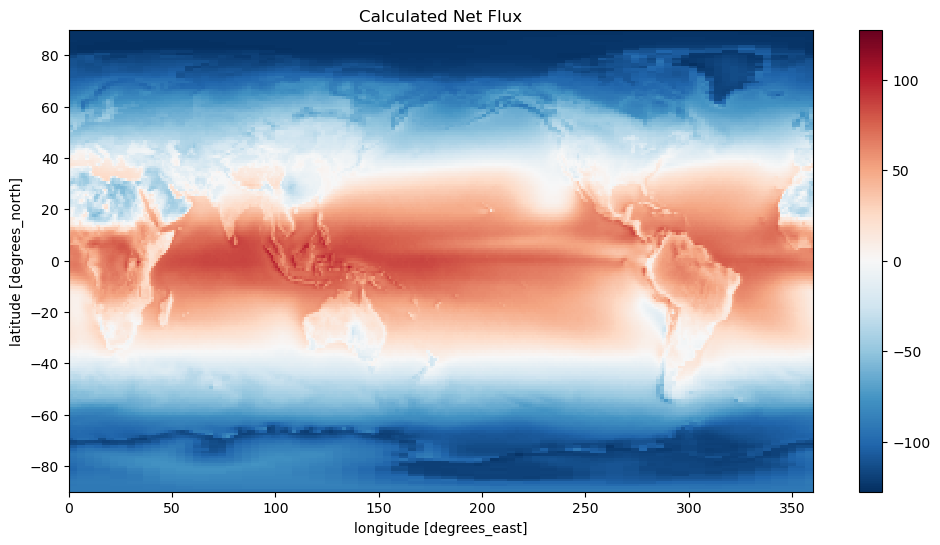

In [205]:
calc_net = time_mean.solar_mon - (time_mean.toa_lw_all_mon + time_mean.toa_sw_all_mon)
calc_net.plot()
plt.title('Calculated Net Flux')
calc_net.mean()
calc_net_value = calc_net.mean().item()
print(f"Calculated TOA New Flux (W/m^2): {calc_net_value}")

Actual TOA New Flux (W/m^2): -28.72901153564453


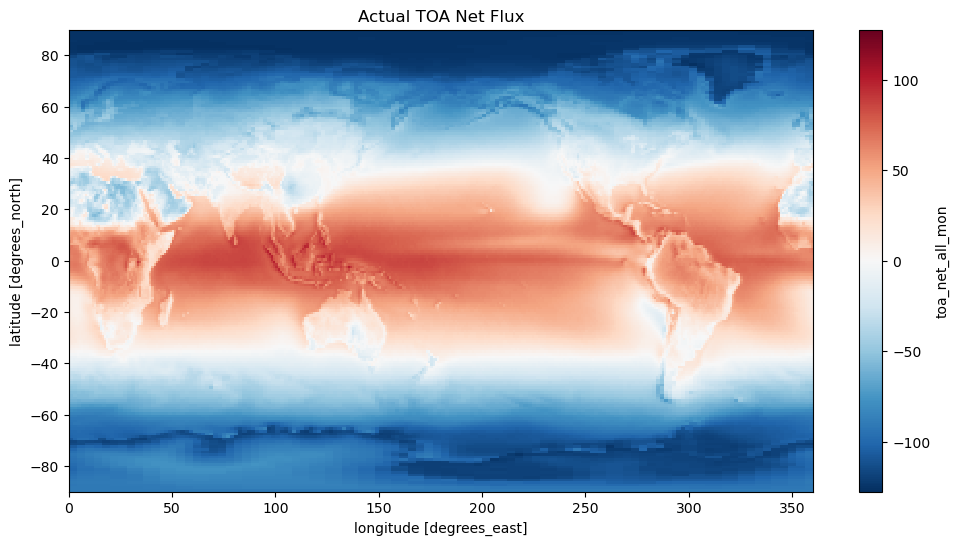

In [206]:
true_net = time_mean.toa_net_all_mon
true_net.plot()
plt.title('Actual TOA Net Flux')
true_net.mean()
true_net_value = true_net.mean().item()
print(f"Actual TOA New Flux (W/m^2): {true_net_value}")

In [207]:
print("Both values are approximately -28.73 W/m^2, so Calculated TOA New Flux and True TOA New Flux are essentially equivalent.")

Both values are approximately -28.73 W/m^2, so Calculated TOA New Flux and True TOA New Flux are essentially equivalent.


## 3) Mean and weighted mean

### 3.1) Calculate the global (unweighted) mean of TOA net radiation

Since the Earth is approximately in radiative balance, the net TOA radiation should be zero. But taking the naive mean from this dataset, you should find a number far from zero. Why?

The answer is that each “pixel” or “grid point” of this dataset does not represent an equal area of Earth’s surface. So naively taking the mean, i.e. giving equal weight to each point, gives the wrong answer.

On a lat / lon grid, the relative area of each grid point is proportional to cos(lambda). (lambda is latitude)

In [208]:
toa_mean_unweighted = ds.toa_net_all_mon.mean().item()
toa_mean_unweighted
print(f"Global (unweighted) mean of TOA net radiation (W/m^2): {toa_mean_unweighted}")

Global (unweighted) mean of TOA net radiation (W/m^2): -28.72901153564453


### 3.2) Create a weight array proportional to cos(lambda)
Think carefully a about radians vs. degrees

In [209]:
weights = np.cos(ds.lat*np.pi/180)
weights

<xarray.DataArray 'lat' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361933, 0.06104851, 0.07845908,
       0.09584564, 0.11320312, 0.13052613, 0.14780948, 0.16504757,
       0.18223551, 0.19936782, 0.21643965, 0.2334453 , 0.25037998,
       0.26723838, 0.28401524, 0.30070582, 0.31730458, 0.3338068 ,
       0.35020736, 0.3665012 , 0.38268346, 0.398749  , 0.4146933 ,
       0.43051106, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.50753826, 0.5224985 , 0.5372996 , 0.551937  , 0.5664062 ,
       0.58070296, 0.59482276, 0.60876137, 0.6225146 , 0.6360782 ,
       0.64944804, 0.66262   , 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.80385685, 0.8141155 ,
       0.8241262 , 0.8338858 , 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.8788171 , 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.9426415 , 0.94832367, 0.95371693, 0.95881975, 0.96363044,
       0.96814764, 0.9723699 , 0.976296  , 0.9799247 , 0.9832549 ,
       0.9862856 , 0.9890159 , 0.9914449 , 0.9935719 , 0.9953962 ,
       0.9969173 , 0.9981348 , 0.99904823, 0.99965733, 0.9999619 ,
       0.9999619 , 0.99965733, 0.99904823, 0.9981348 , 0.9969173 ,
       0.9953962 , 0.9935719 , 0.9914449 , 0.9890159 , 0.9862856 ,
       0.9832549 , 0.9799247 , 0.976296  , 0.9723699 , 0.96814764,
       0.96363044, 0.95881975, 0.95371693, 0.94832367, 0.9426415 ,
       0.9366722 , 0.9304176 , 0.9238795 , 0.9170601 , 0.9099613 ,
       0.90258527, 0.89493436, 0.8870108 , 0.8788171 , 0.87035567,
       0.8616291 , 0.85264015, 0.8433914 , 0.8338858 , 0.8241262 ,
       0.8141155 , 0.80385685, 0.7933533 , 0.78260815, 0.77162457,
       0.76040596, 0.7489557 , 0.7372773 , 0.72537434, 0.71325046,
       0.70090926, 0.68835455, 0.67559016, 0.66262   , 0.64944804,
       0.6360782 , 0.6225146 , 0.60876137, 0.59482276, 0.58070296,
       0.5664062 , 0.551937  , 0.5372996 , 0.5224985 , 0.50753826,
       0.49242356, 0.47715878, 0.4617486 , 0.44619778, 0.43051106,
       0.4146933 , 0.398749  , 0.38268346, 0.3665012 , 0.35020736,
       0.3338068 , 0.31730458, 0.30070582, 0.28401524, 0.26723838,
       0.25037998, 0.2334453 , 0.21643965, 0.19936782, 0.18223551,
       0.16504757, 0.14780948, 0.13052613, 0.11320312, 0.09584564,
       0.07845908, 0.06104851, 0.04361933, 0.02617699, 0.00872656],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5

### 3.3) Redo your global mean TOA net radiation calculation with this weight factor
Use xarray’s weighted array reductions to compute the weighted mean.

This time around, you should have found something much closer to zero. Ask a climate scientist what the net energy imbalance of Earth due to global warming is estimated to be. Do you think our calculation is precise enough to detect this?

In [210]:
weighted_net = ds.toa_net_all_mon.weighted(weights=weights).mean().item()
weighted_net
print(f"Global weighted mean of TOA net radiation (W/m^2): {weighted_net}")

Global weighted mean of TOA net radiation (W/m^2): 0.8780879378318787


I think our calculation is precise enough to detect the energy imbalance of Earth due to global warming because the value of 0.87 W/m^2 is pretty close to 1.0 W/m^2 which is what a climate scientist would estimate to be the net energy imbalance of the Earth.

3.4) Now that you have a weight factor, verify that the TOA incoming solar, outgoing longwave, and outgoing shortwave approximately match up with infographic shown in the first cell of this assignment

In [211]:
# solar_mon: Incoming Solar Flux, Monthly Means
weighted_solar = ds.solar_mon.weighted(weights=weights).mean().item()
weighted_solar
print(f"Global weighted mean of TOA incoming solar radiation (W/m^2): {weighted_solar}")

Global weighted mean of TOA incoming solar radiation (W/m^2): 340.28326416015625


A value of 340.28  W/m^2 for TOA Incoming Solar radiation that I calculated matches with the Incoming Solar radiation of 340.4 W/m^2 in the infographic.

In [212]:
#toa_lw_all_mon: Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
weighted_toa_lw = ds.toa_lw_all_mon.weighted(weights=weights).mean().item()
weighted_toa_lw
print(f"Global weighted mean of TOA longwave radiation (W/m^2): {weighted_toa_lw}")

Global weighted mean of TOA longwave radiation (W/m^2): 240.26690673828125


A value of 240.27  w/m^2 for TOA Longwave Radiation that I calculated matches with the total outgoing infrared radiation of 239.9 W/m^2 in the infographic.

In [213]:
#toa_sw_all_mon: Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
weighted_toa_sw = ds.toa_sw_all_mon.weighted(weights=weights).mean().item()
weighted_toa_sw
print(f"Global weighted mean of TOA shortwave radiation (W/m^2): {weighted_toa_sw}")

Global weighted mean of TOA shortwave radiation (W/m^2): 99.13804626464844


A value of 99.14  W/m^2 for TOA Shortwave Radiation that I calculated matches with the total reflected solar radiation of 99.9 W/m^2 in the infographic.

## 4) Meridional Heat Transport Calculation

We can go beyond a weight factor and actually calculate the area of each pixel of the dataset, using the formula 

dA = (R^2)* cos(lambda) * d lambda * d phi 

where d lambda and d phi are the spacing of the points in latitude and longitude (measured in radians). We can approximate Earth’s radius as R = 6,371 km.

### 4.1) Calculate the pixel area using this formula and create a 2D (lon, lat) DataArray for it
(Xarray’s ones_like function can help you easily create and broadcast DataArrays.) Verify that the sum of all the pixels equals the Earth’s true surface area as evaluated using the formula for the area of a sphere (yes, the Earth is not a sphere … it’s just a homework problem).

In [214]:
R = 6371

d_lambda = np.deg2rad(1.0)
d_phi = np.deg2rad(1.0)   

lat_rad = np.deg2rad(ds.lat)
dA_1D = (R**2) * np.cos(lat_rad) * d_lambda * d_phi
dA_1D

pixel_area = xr.ones_like(ds.lat) * xr.ones_like(ds.lon) * dA_1D

total_area_sum_array = pixel_area.sum()
total_area_sum = total_area_sum_array.item()

earth_true_surface_area = 4 * np.pi * R**2
earth_true_surface_area

print(f"My calculated sum of Earth's surface area: {total_area_sum:.3e} km^2")
print(f"Earth's actual surface area: {earth_true_surface_area:.3e} km^2")
print()
print("Pixel Area 2D DataArray:")
print(pixel_area)

My calculated sum of Earth's surface area: 5.101e+08 km^2
Earth's actual surface area: 5.101e+08 km^2

Pixel Area 2D DataArray:
<xarray.DataArray (lat: 180, lon: 360)> Size: 518kB
array([[107.89792584, 107.89792584, 107.89792584, ..., 107.89792584,
        107.89792584, 107.89792584],
       [323.66052173, 323.66052173, 323.66052173, ..., 323.66052173,
        323.66052173, 323.66052173],
       [539.32452479, 539.32452479, 539.32452479, ..., 539.32452479,
        539.32452479, 539.32452479],
       ...,
       [539.32452479, 539.32452479, 539.32452479, ..., 539.32452479,
        539.32452479, 539.32452479],
       [323.66052173, 323.66052173, 323.66052173, ..., 323.66052173,
        323.66052173, 323.66052173],
       [107.89792584, 107.89792584, 107.89792584, ..., 107.89792584,
        107.89792584, 107.89792584]])
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

## 4.2) Calculate and plot the total amount of net radiation in each 1-degree latitude band
Multiplying the pixel area (m^2) from above with the radiative flux (W m^-2) gives you the total amount of radiation absorbed in each pixel in W.

Label with correct units.

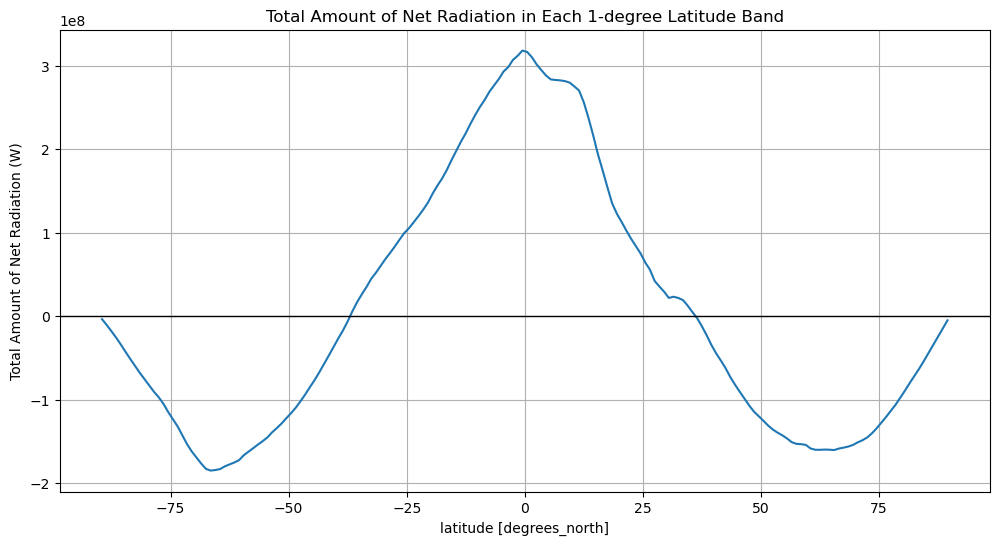

In [215]:
total_net_rad = dA * time_mean.toa_net_all_mon
total_net_rad.sum(dim = ['lon']).plot(x='lat')
total_net_rad
plt.title('Total Amount of Net Radiation in Each 1-degree Latitude Band')
plt.ylabel('Total Amount of Net Radiation (W)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=1)

## 4.3) Plot the cumulative sum of the total amount of net radiation as a function of latitude

Label with correct units. (Hint: check out xarray’s cumsum function.)

This curve tells you how much energy must be transported meridionally by the ocean and atmosphere in order to account for the radiative imbalance at the top of the atmosphere.

You should get a curve that looks something like this: https://journals.ametsoc.org/view/journals/clim/14/16/full-i1520-0442-14-16-3433-f07.gif (Figure from Trenberth & Caron, 2001)

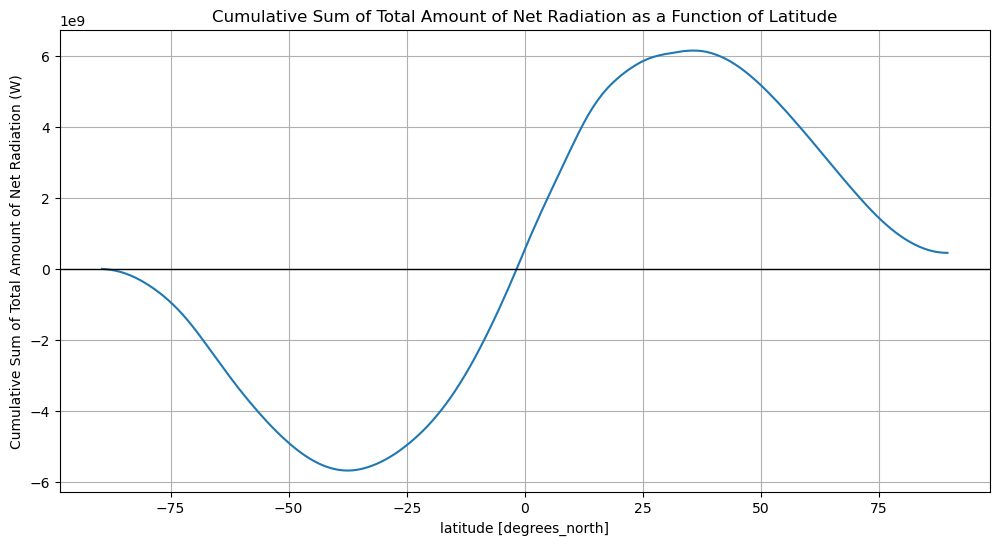

In [216]:
total_net_rad = dA * time_mean.toa_net_all_mon
total_net_rad.sum(dim = ['lon']).cumsum().plot()
plt.title('Cumulative Sum of Total Amount of Net Radiation as a Function of Latitude')
plt.ylabel('Cumulative Sum of Total Amount of Net Radiation (W)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=1)

## 5) Making Maps with Cartopy

5.1) Plot data from NARR

NARR is NCEP’s North American Regional Reanalysis, a widely used product for studying the weather and climate of the continental US. The data is available from NOAA’s Earth System Research Laboratory via OPeNDAP, meaing that xarray can open the data “remotely” without downloading a file.

For this problem, you should open this geopential height file:

https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/pressure/hgt.201810.nc

And this precipitation file:

https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/monolevel/apcp.2018.nc

In [217]:
# Skip 5.1

## 5.2) Antarctic Sea Ice

Download this file and then use it to plot the concentration of Antarctic Sea Ice on Aug. 7, 2017. Again, you will need to explore the file contents in order to determine the correct projection.

In [218]:
import xarray as xr
import pooch
url = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname = pooch.retrieve(url, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname, drop_variables='melt_onset_day_seaice_conc_cdr')

In [219]:
ds_ice

<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:                             Comiso, J. C., and F. Nishio. 200...
    program:                                NOAA Climate Data Record Program
    cdr_variable:                           seaice_conc_cdr
    software_version_id:                    git@bitbucket.org:nsidc/seaice_cd...
    Metadata_Link:                          https://nsidc.org/api/dataset/met...
    product_version:                        v03r01
    ...                                     ...
    scaling_factor:                         1.0
    false_easting:                          0.0
    false_northing:                         0.0
    semimajor_radius:                       6378273.0
    semiminor_radius:                       6356889.449
    proj_units:                             meters

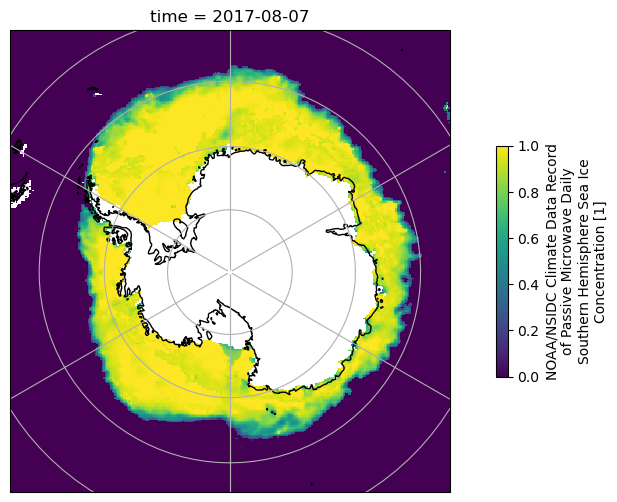

In [220]:
# Use South Polar Stereo projection from cartopy
projection = ccrs.SouthPolarStereo()
ax = plt.axes(projection = projection)
ax.coastlines()
ax.gridlines()

ds_ice = ds_ice.where(ds_ice.seaice_conc_cdr <= 1)
ds_ice.seaice_conc_cdr.sel(time = '2017-08-07').plot(vmin = 0, vmax = 1, extend = 'neither', cbar_kwargs={'shrink':0.5})

plt.title("time = 2017-08-07") 
plt.show()

## 5.3) Global USGS Earthquakes

In [221]:
import pandas as pd

Reload the file we explored in homework 5 using pandas and use the data to recreate this map.

In [222]:
url = 'http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv'
df = pd.read_csv(url, parse_dates=['time','updated'], index_col = 'id')
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05 19:34:41.515000+00:00,"26km S of Redoubt Volcano, Alaska",earthquake
nn00436847,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,2014-02-01 01:35:09+00:00,"32km S of Alamo, Nevada",earthquake
ak11151142,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01 00:03:53.010000+00:00,"12km NNW of North Nenana, Alaska",earthquake
ak11151135,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31 23:41:25.007000+00:00,"22km S of Cantwell, Alaska",earthquake
ci37171541,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,2014-02-01 00:13:20.107000+00:00,"10km WNW of Progreso, Mexico",earthquake


In [223]:
largest50 = df.nlargest(50,'mag')
largest50.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
usc000nzvd,2014-04-01 23:46:47.260,-19.6097,-70.7691,25.00,8.2,mww,NaN,23.0,0.609,0.66,us,2015-07-30 16:24:51.223000+00:00,"94km NW of Iquique, Chile",earthquake
usc000rki5,2014-06-23 20:53:09.700,51.8486,178.7352,109.00,7.9,mww,NaN,22.0,0.133,0.71,us,2015-04-18 21:54:08.699000+00:00,"19km SE of Little Sitkin Island, Alaska",earthquake
usc000p27i,2014-04-03 02:43:13.110,-20.5709,-70.4931,22.40,7.7,mww,NaN,44.0,1.029,0.82,us,2015-06-06 07:31:05.755000+00:00,"53km SW of Iquique, Chile",earthquake
usc000phx5,2014-04-12 20:14:39.300,-11.2701,162.1481,22.56,7.6,mww,NaN,13.0,2.828,0.71,us,2015-04-18 21:54:27.398000+00:00,"93km SSE of Kirakira, Solomon Islands",earthquake
usb000pr89,2014-04-19 13:28:00.810,-6.7547,155.0241,43.37,7.5,mww,NaN,16.0,3.820,1.25,us,2015-04-18 21:54:18.633000+00:00,"70km SW of Panguna, Papua New Guinea",earthquake


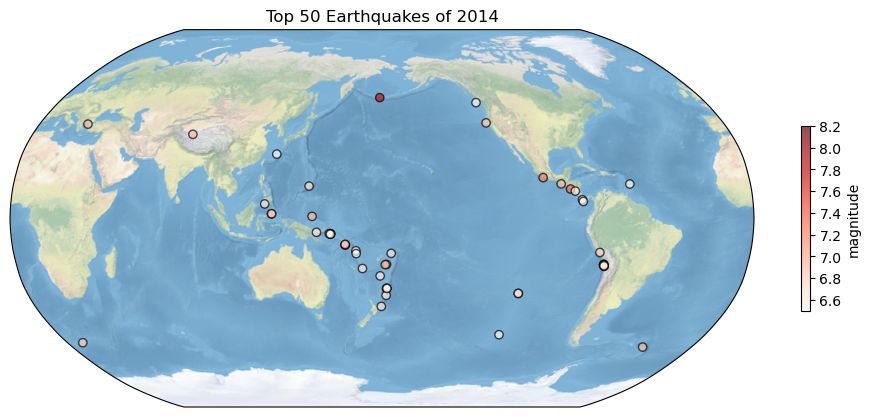

In [224]:
fig = plt.figure()
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.stock_img()
ax.set_title('Top 50 Earthquakes of 2014')

sc = ax.scatter(largest50['longitude'], largest50['latitude'], 
                 c=largest50['mag'],
                 cmap='Reds', 
                 alpha=0.7,
                edgecolors='black',
                 transform=ccrs.PlateCarree())


plt.colorbar(sc, label='magnitude', shrink=0.4, ticks=np.arange(6.6, 8.4, 0.2))
plt.show()